# 04 — Model Interpretability
Load best_model.pkl → SHAP → LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=17b9732767542c4e0a77e6cb33ec89be86399ac9688681f4a7a3c24d70cf2dab
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
import shap
import lime
import lime.lime_tabular

RS = 42

##Load Best Model

In [ ]:
drive.mount('/content/drive')
model_path = '/content/drive/MyDrive/Maternal_Health_Model/best_model_final.pkl'

with open(model_path, 'rb') as f:
    payload = pickle.load(f)

best_pipe = payload['model']
threshold = payload['threshold']
feature_names = payload['feature_names']

print("Best model berhasil dimuat")
print(f"Threshold          : {threshold}")
print(f"Jumlah fitur       : {len(feature_names)}")
print(f"Nama fitur         : {feature_names}")


Mounted at /content/drive
Best model berhasil dimuat
Threshold          : 0.42
Jumlah fitur       : 9
Nama fitur         : ['Age', 'Systolic BP', 'Diastolic', 'BMI', 'Heart Rate', 'Pulse Pressure', 'MAP', 'Previous Complications', 'Is_Fever']


In [ ]:
# Load test and train data
X_train_B_PP_rc = pd.read_csv('/content/drive/MyDrive/Maternal_Health_Model/X_train_B_PP_rc.csv')
X_test = pd.read_csv('/content/drive/MyDrive/Maternal_Health_Model/X_test_B_PP_rc.csv')
y_test = pd.read_csv('/content/drive/MyDrive/Maternal_Health_Model/y_test.csv').iloc[:, 0]

print(f"Test set berhasil dimuat: {X_test.shape}")
print(f"Distribusi target: {y_test.value_counts().to_dict()}")

Test set berhasil dimuat: (234, 9)
Distribusi target: {0: 139, 1: 95}


##SHAP

SHAP INTERPRETABILITY ANALYSIS
SHAP values berhasil dihitung. Shape: (234, 9)


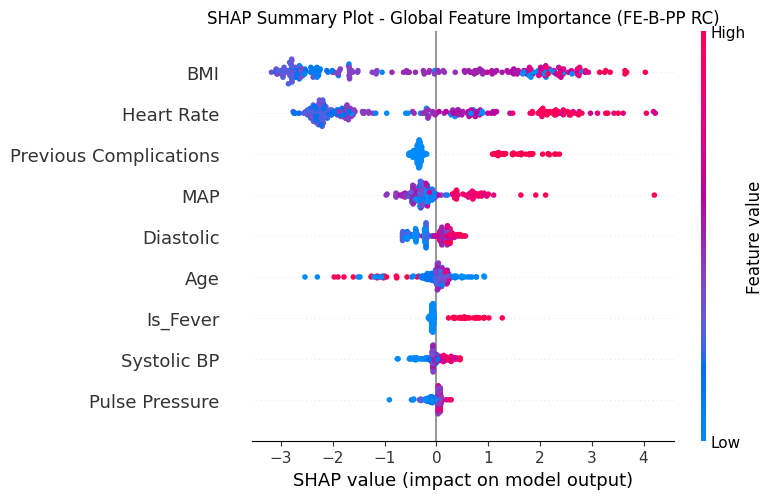

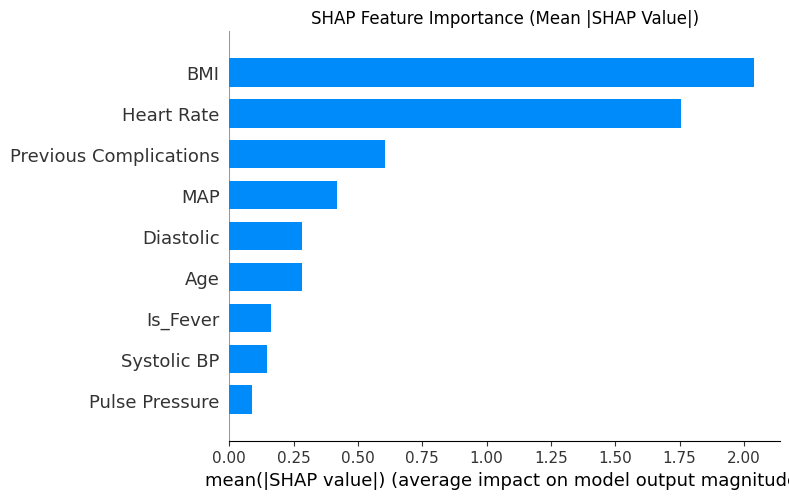


SHAP Waterfall Plot untuk 3 contoh kasus:

--- Low Risk Example (Index 0) ---


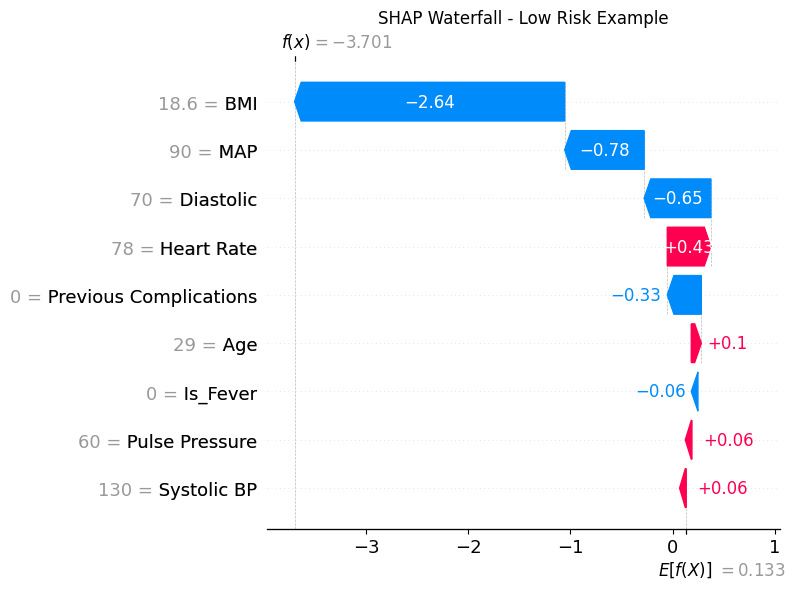


--- Borderline Case (Index 4) ---


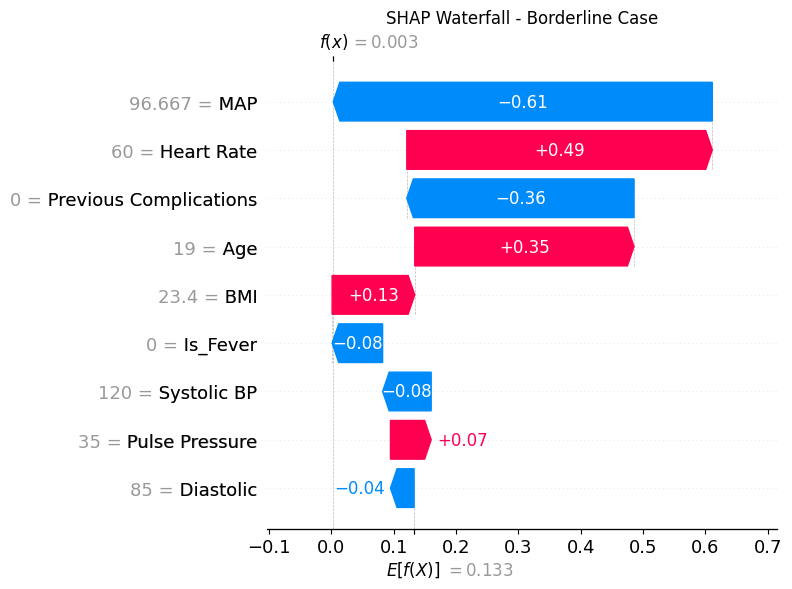


--- High Risk Example (Index 1) ---


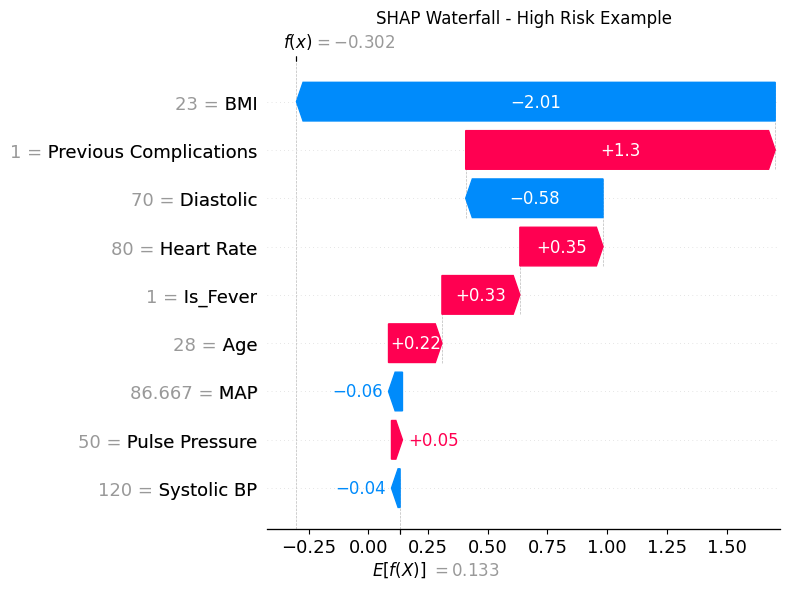

In [ ]:
print("SHAP INTERPRETABILITY ANALYSIS")

explainer = shap.TreeExplainer(best_pipe.named_steps['clf'])
shap_values = explainer.shap_values(X_test)

print(f"SHAP values berhasil dihitung. Shape: {shap_values.shape}")

#SHAP Global Summary Plot (Beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="dot", show=False)
plt.title("SHAP Summary Plot - Global Feature Importance (FE-B-PP RC)")
plt.tight_layout()
plt.show()

#SHAP Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP Value|)")
plt.tight_layout()
plt.show()

#SHAP Waterfall Plot untuk 3 contoh kasus
print("\nSHAP Waterfall Plot untuk 3 contoh kasus:")

idx_high = y_test[y_test == 1].index[0]
idx_low  = y_test[y_test == 0].index[0]
idx_mid  = np.argmin(np.abs(best_pipe.predict_proba(X_test)[:, 1] - 0.5))

indices = [idx_low, idx_mid, idx_high]
labels = ["Low Risk Example", "Borderline Case", "High Risk Example"]

for i, idx in enumerate(indices):
    print(f"\n--- {labels[i]} (Index {idx}) ---")

    shap.plots.waterfall(shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx],
        feature_names=feature_names
    ), show=False)

    plt.title(f"SHAP Waterfall - {labels[i]}")
    plt.tight_layout()
    plt.show()

## LIME

LIME INTERPRETABILITY ANALYSIS

--- LIME Explanation for Low Risk Example (Index 0) ---


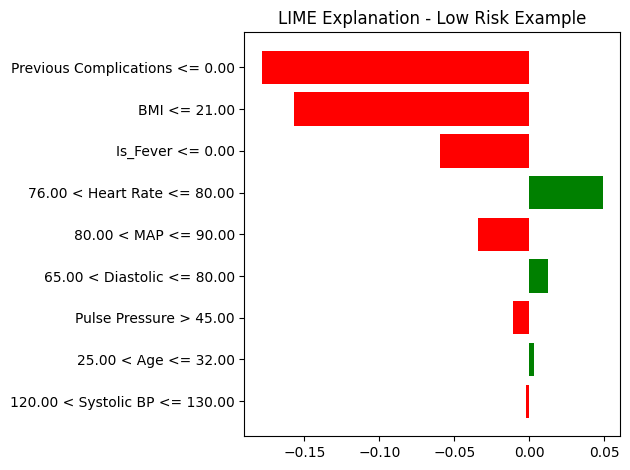

Top 5 contributing features:
   Previous Complications <= 0.00           : -0.1785
   BMI <= 21.00                             : -0.1571
   Is_Fever <= 0.00                         : -0.0598
   76.00 < Heart Rate <= 80.00              : +0.0492
   80.00 < MAP <= 90.00                     : -0.0338

--- LIME Explanation for Borderline Case (Index 4) ---


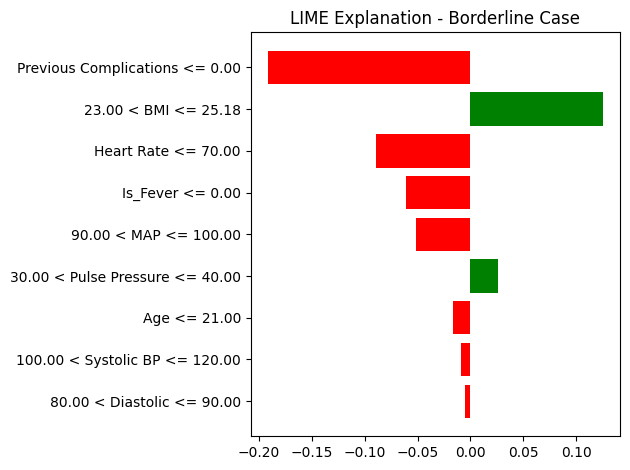

Top 5 contributing features:
   Previous Complications <= 0.00           : -0.1917
   23.00 < BMI <= 25.18                     : +0.1254
   Heart Rate <= 70.00                      : -0.0895
   Is_Fever <= 0.00                         : -0.0607
   90.00 < MAP <= 100.00                    : -0.0518

--- LIME Explanation for High Risk Example (Index 1) ---


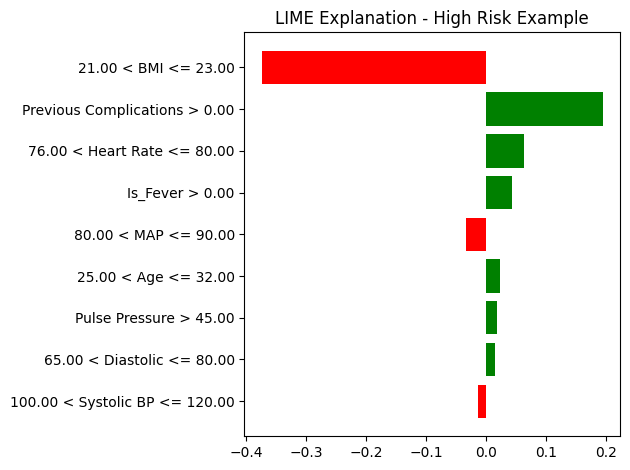

Top 5 contributing features:
   21.00 < BMI <= 23.00                     : -0.3746
   Previous Complications > 0.00            : +0.1944
   76.00 < Heart Rate <= 80.00              : +0.0623
   Is_Fever > 0.00                          : +0.0423
   80.00 < MAP <= 90.00                     : -0.0337


In [ ]:
print("LIME INTERPRETABILITY ANALYSIS")

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_B_PP_rc.values,
    feature_names=feature_names,
    class_names=['Low Risk', 'High Risk'],
    mode='classification',
    discretize_continuous=True,
    random_state=RS
)


idx_low  = y_test[y_test == 0].index[0]
idx_high = y_test[y_test == 1].index[0]
idx_mid  = np.argmin(np.abs(best_pipe.predict_proba(X_test)[:, 1] - 0.5))

indices = [idx_low, idx_mid, idx_high]
labels  = ["Low Risk Example", "Borderline Case", "High Risk Example"]

for i, idx in enumerate(indices):
    print(f"\n--- LIME Explanation for {labels[i]} (Index {idx}) ---")

    exp = explainer_lime.explain_instance(
        data_row=X_test.iloc[idx].values,
        predict_fn=best_pipe.predict_proba,
        num_features=10
    )

    exp.as_pyplot_figure()
    plt.title(f"LIME Explanation - {labels[i]}")
    plt.tight_layout()
    plt.show()

    print("Top 5 contributing features:")
    for feature, weight in exp.as_list()[:5]:
        print(f"   {feature:40} : {weight:+.4f}")


## Insight dari SHAP Analysis

### Global Feature Importance
- **BMI** adalah fitur paling berpengaruh secara keseluruhan.
- **Heart Rate** berada di posisi kedua.
- **Previous Complications** memiliki pengaruh yang kuat dan tajam.
- **MAP**, **Diastolic BP**, dan **Age** memiliki kontribusi sedang.
- Fitur lain (Is_Fever, Systolic BP, Pulse Pressure) memiliki pengaruh yang lebih kecil.

### Local Explanation (Waterfall Plot)
- Pada kasus **Low Risk**: BMI rendah memberikan kontribusi negatif terbesar.
- Pada kasus **High Risk**: Kombinasi BMI tinggi dan Previous Complications = 1 menjadi pendorong utama risiko tinggi.
- Pada kasus **Borderline**: MAP dan Heart Rate memberikan kontribusi yang saling bertentangan.

## Insight dari LIME

- Previous Complications dan BMI konsisten muncul sebagai kontributor utama.
- Pada kasus High Risk, Previous Complications > 0 dan BMI di rentang tertentu sangat meningkatkan probabilitas risiko tinggi.
- Pada kasus Low Risk, Previous Complications = 0 dan BMI rendah sangat mendukung prediksi Low Risk.
- Penjelasan lokal dari LIME selaras dengan hasil SHAP.

## Ringkasan Interpretability

Hasil SHAP dan LIME menunjukkan bahwa model cukup stabil dan dapat dijelaskan. Faktor-faktor yang paling menentukan prediksi adalah **BMI**, **Heart Rate**, dan **Previous Complications**. Hal ini sesuai dengan pengetahuan klinis mengenai risiko kesehatan ibu hamil.

Interpretability ini menjadi dasar untuk pengembangan **Clinical Scoring System** di bagian selanjutnya.

## Clinical Scoring System (Berdasarkan SHAP & LIME)

**Detail Bobot Skor**  
Bobot pada tabel di bawah ini diambil langsung dari hasil SHAP dan LIME yang kamu jalankan.

| Faktor Risiko          | Bobot | Alasan dari SHAP (dari gambar kamu)                              |
|------------------------|-------|------------------------------------------------------------------|
| Previous Complications | 5     | Peringkat 3 tapi dampaknya sangat tajam di waterfall (bisa +1.3) |
| BMI                    | 4     | Paling tinggi di bar plot (mean \|SHAP value\| tertinggi)       |
| Heart Rate             | 3     | Peringkat 2 di bar plot                                          |
| MAP                    | 3     | Peringkat 4, cukup kuat di waterfall                             |
| Systolic BP            | 2     | Muncul di waterfall meski ranking rendah                         |
| Diastolic BP           | 2     | Muncul di waterfall                                              |
| Age                    | 2     | Peringkat 6, sedang                                              |
| Is_Fever               | 1     | Peringkat rendah tapi tetap ada di model                         |
| Pulse Pressure         | 1     | Paling rendah di bar plot                                        |

**Tabel Clinical Scoring System**

| No | Faktor Risiko                  | Kondisi                                      | Bobot Skor |
|----|--------------------------------|----------------------------------------------|------------|
| 1  | Previous Complications         | Pernah ada (Yes = 1)                         | 5          |
| 2  | BMI                            | ≥ 30 (Obesitas)                              | 4          |
| 3  | BMI                            | 25.0 – 29.9 (Overweight)                     | 2          |
| 4  | Heart Rate                     | ≥ 90 bpm                                     | 3          |
| 5  | MAP (Mean Arterial Pressure)   | ≥ 105 mmHg                                   | 3          |
| 6  | Systolic BP                    | ≥ 140 mmHg                                   | 2          |
| 7  | Diastolic BP                   | ≥ 90 mmHg                                    | 2          |
| 8  | Age                            | ≥ 35 tahun                                   | 2          |
| 9  | Is_Fever                       | Ya (> 37.5°C)                                | 1          |
| 10 | Pulse Pressure                 | ≥ 60 mmHg                                    | 1          |

**Cara Penghitungan:**
- Jumlahkan semua bobot sesuai kondisi pasien.
- **Total Skor ≥ 7**   → **High Risk**
- **Total Skor < 7**    → **Low Risk**

**Catatan:**
- BMI < 25 → skor BMI = 0
- MAP = DiastolicBP + (SystolicBP − DiastolicBP) / 3
- Pulse Pressure = SystolicBP − DiastolicBP
- Is_Fever = df["Body Temp"] > 99
- Semua fitur sesuai dengan model FE-B-PP RC.

#LANJUT BESOK :)

In [ ]:
# ================================================
# VERSI 1 + SENSITIVITY ANALYSIS Previous Complications
# ================================================

import pandas as pd
import pickle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df_ext = pd.read_csv("https://raw.githubusercontent.com/alifnw/3-Alif-Livyandra/refs/heads/livyandra/Mathernal_Risk.csv")

# Preprocessing FE-B-PP
df_ext = df_ext.rename(columns={
    'Age': 'Age', 'Systolic Blood Pressure(mm Hg)': 'Systolic BP',
    'Diastolic Blood Pressure(mm Hg)': 'Diastolic', 'BMI(kg/m 2)': 'BMI',
    'Heart rate(bpm)': 'Heart Rate', 'Body Temperature(F) ': 'Body Temp'
})

df_ext['Pulse Pressure'] = df_ext['Systolic BP'] - df_ext['Diastolic']
df_ext['MAP'] = (df_ext['Systolic BP'] + 2*df_ext['Diastolic'])/3
df_ext['Is_Fever'] = (df_ext['Body Temp'] > 99).astype(int)

target = df_ext['Status'].copy()
df_ext = df_ext.drop(columns=['Patient ID','Name','Blood Glucose(HbA1c)',
                              'Blood Glucose(Fasting hour-mg/dl)','Status'], errors='ignore')
df_ext['Status'] = target

df_ext = df_ext[df_ext['Status'] != 'mid risk'].reset_index(drop=True)
df_ext['Risk Level'] = df_ext['Status'].map({'high risk':1, 'low risk':0})

# Load model
with open('/content/drive/MyDrive/Maternal_Health_Model/best_model_final.pkl', 'rb') as f:
    payload = pickle.load(f)

model = payload['model']
feature_names = payload['feature_names']

# Sensitivity Analysis
scenarios = [0, 1]   # bisa ditambah 0.25 kalau mau netral
print("=== SENSITIVITY ANALYSIS Previous Complications ===\n")

for val in scenarios:
    df_temp = df_ext.copy()
    df_temp['Previous Complications'] = val

    # Tambah kolom yang mungkin kurang
    for col in feature_names:
        if col not in df_temp.columns:
            df_temp[col] = 0

    X = df_temp[feature_names]
    y = df_temp['Risk Level']
    y_pred = model.predict(X)

    print(f"Previous Complications = {val}")
    print(classification_report(y, y_pred, target_names=["Low Risk","High Risk"], digits=4))

    cm = confusion_matrix(y, y_pred)
    print(f"False Negative (missed high risk): {cm[1,0]}")
    print("-"*60)

=== SENSITIVITY ANALYSIS Previous Complications ===

Previous Complications = 0
              precision    recall  f1-score   support

    Low Risk     0.6364    0.6017    0.6185      2001
   High Risk     0.6324    0.6659    0.6487      2059

    accuracy                         0.6342      4060
   macro avg     0.6344    0.6338    0.6336      4060
weighted avg     0.6343    0.6342    0.6338      4060

False Negative (missed high risk): 688
------------------------------------------------------------
Previous Complications = 1
              precision    recall  f1-score   support

    Low Risk     0.6553    0.5387    0.5913      2001
   High Risk     0.6178    0.7246    0.6670      2059

    accuracy                         0.6330      4060
   macro avg     0.6366    0.6317    0.6291      4060
weighted avg     0.6363    0.6330    0.6297      4060

False Negative (missed high risk): 567
------------------------------------------------------------


In [ ]:
# ================================================
# VERSI 2 — MID RISK GABUNG HIGH RISK + Sensitivity
# ================================================

import pandas as pd
import pickle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df_ext = pd.read_csv("https://raw.githubusercontent.com/alifnw/3-Alif-Livyandra/refs/heads/livyandra/Mathernal_Risk.csv")

# Preprocessing FE-B-PP
df_ext = df_ext.rename(columns={
    'Age': 'Age',
    'Systolic Blood Pressure(mm Hg)': 'Systolic BP',
    'Diastolic Blood Pressure(mm Hg)': 'Diastolic',
    'BMI(kg/m 2)': 'BMI',
    'Heart rate(bpm)': 'Heart Rate',
    'Body Temperature(F) ': 'Body Temp'
})

df_ext['Pulse Pressure'] = df_ext['Systolic BP'] - df_ext['Diastolic']
df_ext['MAP'] = (df_ext['Systolic BP'] + 2 * df_ext['Diastolic']) / 3
df_ext['Is_Fever'] = (df_ext['Body Temp'] > 99).astype(int)

# Handle missing feature
df_ext['Previous Complications'] = 0

target = df_ext['Status'].copy()
df_ext = df_ext.drop(columns=['Patient ID','Name','Blood Glucose(HbA1c)',
                              'Blood Glucose(Fasting hour-mg/dl)','Status'], errors='ignore')
df_ext['Status'] = target

# VERSI 2: Mid Risk → High Risk
df_ext['Risk Level'] = df_ext['Status'].map({
    'high risk': 1,
    'mid risk': 1,     # ← gabung ke High
    'low risk': 0
})

print("Versi 2 — Mid Risk gabung High Risk")
print(f"Jumlah sampel: {len(df_ext)}")
print("Distribusi target:\n", df_ext['Risk Level'].value_counts())

# Load model
with open('/content/drive/MyDrive/Maternal_Health_Model/best_model_final.pkl', 'rb') as f:
    payload = pickle.load(f)

model = payload['model']
feature_names = payload['feature_names']

# Sensitivity Analysis
scenarios = [0, 1]
print("\n=== SENSITIVITY ANALYSIS Versi 2 ===\n")

for val in scenarios:
    df_temp = df_ext.copy()
    df_temp['Previous Complications'] = val

    for col in feature_names:
        if col not in df_temp.columns:
            df_temp[col] = 0

    X = df_temp[feature_names]
    y = df_temp['Risk Level']
    y_pred = model.predict(X)

    print(f"Previous Complications = {val}")
    print(classification_report(y, y_pred, target_names=["Low Risk", "High Risk"], digits=4))
    cm = confusion_matrix(y, y_pred)
    print(f"False Negative: {cm[1,0]} | False Positive: {cm[0,1]}")
    print("-" * 70)

Versi 2 — Mid Risk gabung High Risk
Jumlah sampel: 6103
Distribusi target:
 Risk Level
1    4102
0    2001
Name: count, dtype: int64

=== SENSITIVITY ANALYSIS Versi 2 ===

Previous Complications = 0
              precision    recall  f1-score   support

    Low Risk     0.4431    0.6017    0.5104      2001
   High Risk     0.7646    0.6312    0.6915      4102

    accuracy                         0.6215      6103
   macro avg     0.6039    0.6164    0.6009      6103
weighted avg     0.6592    0.6215    0.6321      6103

False Negative: 1513 | False Positive: 797
----------------------------------------------------------------------
Previous Complications = 1
              precision    recall  f1-score   support

    Low Risk     0.4615    0.5387    0.4971      2001
   High Risk     0.7550    0.6933    0.7228      4102

    accuracy                         0.6426      6103
   macro avg     0.6082    0.6160    0.6100      6103
weighted avg     0.6587    0.6426    0.6488      6103

False 

In [ ]:
# ================================================
# VERSI 3 — MID RISK GABUNG LOW RISK + Sensitivity
# ================================================

# (Copy dari Versi 2, hanya ubah bagian mapping target saja)

# ... (bagian preprocessing sampai sebelum mapping target sama seperti Versi 2)
import pandas as pd
import pickle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df_ext = pd.read_csv("https://raw.githubusercontent.com/alifnw/3-Alif-Livyandra/refs/heads/livyandra/Mathernal_Risk.csv")

# Preprocessing FE-B-PP
df_ext = df_ext.rename(columns={
    'Age': 'Age',
    'Systolic Blood Pressure(mm Hg)': 'Systolic BP',
    'Diastolic Blood Pressure(mm Hg)': 'Diastolic',
    'BMI(kg/m 2)': 'BMI',
    'Heart rate(bpm)': 'Heart Rate',
    'Body Temperature(F) ': 'Body Temp'
})

df_ext['Pulse Pressure'] = df_ext['Systolic BP'] - df_ext['Diastolic']
df_ext['MAP'] = (df_ext['Systolic BP'] + 2 * df_ext['Diastolic']) / 3
df_ext['Is_Fever'] = (df_ext['Body Temp'] > 99).astype(int)

# Handle missing feature
df_ext['Previous Complications'] = 0

target = df_ext['Status'].copy()
df_ext = df_ext.drop(columns=['Patient ID','Name','Blood Glucose(HbA1c)',
                              'Blood Glucose(Fasting hour-mg/dl)','Status'], errors='ignore')
df_ext['Status'] = target

# VERSI 3: Mid Risk → Low Risk
df_ext['Risk Level'] = df_ext['Status'].map({
    'high risk': 1,
    'mid risk': 0,     # ← gabung ke Low
    'low risk': 0
})

print("Versi 3 — Mid Risk gabung Low Risk")
print(f"Jumlah sampel: {len(df_ext)}")
print("Distribusi target:\n", df_ext['Risk Level'].value_counts())

# Load model (sama)
with open('/content/drive/MyDrive/Maternal_Health_Model/best_model_final.pkl', 'rb') as f:
    payload = pickle.load(f)

model = payload['model']
feature_names = payload['feature_names']

# Sensitivity Analysis
scenarios = [0, 1]
print("\n=== SENSITIVITY ANALYSIS Versi 3 ===\n")

for val in scenarios:
    df_temp = df_ext.copy()
    df_temp['Previous Complications'] = val

    for col in feature_names:
        if col not in df_temp.columns:
            df_temp[col] = 0

    X = df_temp[feature_names]
    y = df_temp['Risk Level']
    y_pred = model.predict(X)

    print(f"Previous Complications = {val}")
    print(classification_report(y, y_pred, target_names=["Low Risk", "High Risk"], digits=4))
    cm = confusion_matrix(y, y_pred)
    print(f"False Negative: {cm[1,0]} | False Positive: {cm[0,1]}")
    print("-" * 70)

Versi 3 — Mid Risk gabung Low Risk
Jumlah sampel: 6103
Distribusi target:
 Risk Level
0    4044
1    2059
Name: count, dtype: int64

=== SENSITIVITY ANALYSIS Versi 3 ===

Previous Complications = 0
              precision    recall  f1-score   support

    Low Risk     0.7468    0.5017    0.6002      4044
   High Risk     0.4049    0.6659    0.5036      2059

    accuracy                         0.5571      6103
   macro avg     0.5758    0.5838    0.5519      6103
weighted avg     0.6314    0.5571    0.5676      6103

False Negative: 688 | False Positive: 2015
----------------------------------------------------------------------
Previous Complications = 1
              precision    recall  f1-score   support

    Low Risk     0.7573    0.4374    0.5545      4044
   High Risk     0.3961    0.7246    0.5122      2059

    accuracy                         0.5343      6103
   macro avg     0.5767    0.5810    0.5334      6103
weighted avg     0.6354    0.5343    0.5403      6103

False N

In [ ]:
# ================================================
# EXTERNAL VALIDATION — 3 VERSI + SENSITIVITY (SUDAH DIFIX)
# ================================================

import pandas as pd
import pickle
from sklearn.metrics import classification_report, confusion_matrix

df_ext = pd.read_csv("https://raw.githubusercontent.com/alifnw/3-Alif-Livyandra/refs/heads/livyandra/Mathernal_Risk.csv")

# Preprocessing FE-B-PP RC
df_ext = df_ext.rename(columns={
    'Age': 'Age',
    'Systolic Blood Pressure(mm Hg)': 'Systolic BP',
    'Diastolic Blood Pressure(mm Hg)': 'Diastolic',
    'BMI(kg/m 2)': 'BMI',
    'Heart rate(bpm)': 'Heart Rate',
    'Body Temperature(F) ': 'Body Temp'
})

df_ext['Pulse Pressure'] = df_ext['Systolic BP'] - df_ext['Diastolic']
df_ext['MAP'] = (df_ext['Systolic BP'] + 2 * df_ext['Diastolic']) / 3
df_ext['Is_Fever'] = (df_ext['Body Temp'] > 99).astype(int)
df_ext['Previous Complications'] = 0   # default

# Simpan target
target = df_ext['Status'].copy()

# Drop kolom tidak dipakai
df_ext = df_ext.drop(columns=['Patient ID', 'Name', 'Blood Glucose(HbA1c)',
                              'Blood Glucose(Fasting hour-mg/dl)', 'Status'], errors='ignore')
df_ext['Status'] = target

# Load model
with open('/content/drive/MyDrive/Maternal_Health_Model/best_model_final.pkl', 'rb') as f:
    payload = pickle.load(f)

model = payload['model']
feature_names = payload['feature_names']

# Fungsi experiment (sudah anti-NaN)
def run_experiment(version_name, risk_mapping):
    df = df_ext.copy()
    df['Risk Level'] = df['Status'].map(risk_mapping)
    df = df.dropna(subset=['Risk Level']).reset_index(drop=True)   # hapus NaN

    results = []
    for val in [0, 1]:
        df_temp = df.copy()
        df_temp['Previous Complications'] = val

        for col in feature_names:
            if col not in df_temp.columns:
                df_temp[col] = 0

        X = df_temp[feature_names]
        y = df_temp['Risk Level']
        y_pred = model.predict(X)

        report = classification_report(y, y_pred, target_names=["Low Risk", "High Risk"], output_dict=True, digits=4)
        cm = confusion_matrix(y, y_pred)

        results.append({
            'Version': version_name,
            'Prev_Complications': val,
            'Recall_High': round(report['High Risk']['recall'], 4),
            'FN': cm[1,0],
            'Accuracy': round(report['accuracy'], 4),
            'F1_High': round(report['High Risk']['f1-score'], 4),
            'Jumlah_Sampel': len(y)
        })
    return pd.DataFrame(results)

# Jalankan 3 versi
v1 = run_experiment("V1_Drop_Mid",      {'high risk':1, 'low risk':0})
v2 = run_experiment("V2_Mid_to_High",   {'high risk':1, 'mid risk':1, 'low risk':0})
v3 = run_experiment("V3_Mid_to_Low",    {'high risk':1, 'mid risk':0, 'low risk':0})

summary = pd.concat([v1, v2, v3], ignore_index=True)
print("=== TABEL PERBANDINGAN EXTERNAL VALIDATION ===")
display(summary)

summary.to_excel("External_Validation_Comparison.xlsx", index=False)
print("\n✅ Tabel disimpan ke External_Validation_Comparison.xlsx")

=== TABEL PERBANDINGAN EXTERNAL VALIDATION ===


,Version,Prev_Complications,Recall_High,FN,Accuracy,F1_High,Jumlah_Sampel
0,V1_Drop_Mid,0,0.6659,688,0.6342,0.6487,4060
1,V1_Drop_Mid,1,0.7246,567,0.6330,0.6670,4060
2,V2_Mid_to_High,0,0.6312,1513,0.6215,0.6915,6103
3,V2_Mid_to_High,1,0.6933,1258,0.6426,0.7228,6103
4,V3_Mid_to_Low,0,0.6659,688,0.5571,0.5036,6103
5,V3_Mid_to_Low,1,0.7246,567,0.5343,0.5122,6103



✅ Tabel disimpan ke External_Validation_Comparison.xlsx


Jumlah data awal: 6103
Jumlah data Pseudo External Test: 1221

CLASSIFICATION REPORT — PSEUDO EXTERNAL VALIDATION
              precision    recall  f1-score   support

    Low Risk     0.7409    0.5056    0.6010       809
   High Risk     0.4021    0.6529    0.4977       412

    accuracy                         0.5553      1221
   macro avg     0.5715    0.5792    0.5494      1221
weighted avg     0.6266    0.5553    0.5662      1221



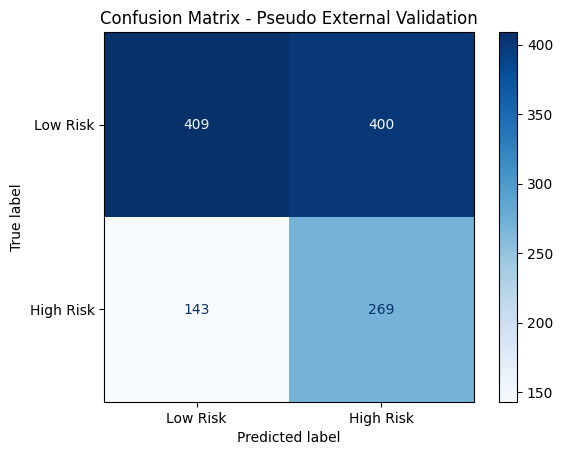

False Negative (High Risk terlewat): 143


In [ ]:
# ================================================
# PSEUDO EXTERNAL VALIDATION (Sangat Simpel)
# ================================================

import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load dataset ASLI kamu (dataset yang kamu pakai untuk training)
df = pd.read_csv("https://raw.githubusercontent.com/alifnw/3-Alif-Livyandra/refs/heads/livyandra/Mathernal_Risk.csv")   # ganti path kalau beda

print("Jumlah data awal:", len(df))

# 2. Preprocessing FE-B-PP RC (sama seperti yang kamu pakai)
df = df.rename(columns={
    'Age': 'Age',
    'Systolic Blood Pressure(mm Hg)': 'Systolic BP',
    'Diastolic Blood Pressure(mm Hg)': 'Diastolic',
    'BMI(kg/m 2)': 'BMI',
    'Heart rate(bpm)': 'Heart Rate',
    'Body Temperature(F) ': 'Body Temp'
})

df['Pulse Pressure'] = df['Systolic BP'] - df['Diastolic']
df['MAP'] = (df['Systolic BP'] + 2 * df['Diastolic']) / 3
df['Is_Fever'] = (df['Body Temp'] > 99).astype(int)
df['Previous Complications'] = 0   # default seperti sebelumnya

# Mapping target (sesuai kebiasaan kamu)
df['Risk Level'] = df['Status'].map({'high risk': 1, 'mid risk': 0, 'low risk': 0})

# 3. Buat Pseudo External Test Set
# Kita ambil 20% data sebagai "data baru" yang tidak pernah dipakai sebelumnya
train_df, pseudo_ext_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,          # ganti angka ini kalau mau split berbeda
    stratify=df['Risk Level'] # biar proporsi high risk tetap sama
)

print(f"Jumlah data Pseudo External Test: {len(pseudo_ext_df)}")

# 4. Load model terbaik kamu
with open('/content/drive/MyDrive/Maternal_Health_Model/best_model_final.pkl', 'rb') as f:
    payload = pickle.load(f)

model = payload['model']
feature_names = payload['feature_names']

# 5. Prediksi di Pseudo External Test
X_pseudo = pseudo_ext_df[feature_names]
y_pseudo = pseudo_ext_df['Risk Level']
y_pred_pseudo = model.predict(X_pseudo)

# 6. Hasil
print("\n" + "="*70)
print("CLASSIFICATION REPORT — PSEUDO EXTERNAL VALIDATION")
print("="*70)
print(classification_report(y_pseudo, y_pred_pseudo,
                            target_names=["Low Risk", "High Risk"], digits=4))

cm = confusion_matrix(y_pseudo, y_pred_pseudo)
disp = ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Pseudo External Validation")
plt.show()

print(f"False Negative (High Risk terlewat): {cm[1,0]}")

Jumlah sampel Pseudo External Test: 1221

CLASSIFICATION REPORT — PSEUDO EXTERNAL VALIDATION
              precision    recall  f1-score   support

    Low Risk     0.7409    0.5056    0.6010       809
   High Risk     0.4021    0.6529    0.4977       412

    accuracy                         0.5553      1221
   macro avg     0.5715    0.5792    0.5494      1221
weighted avg     0.6266    0.5553    0.5662      1221



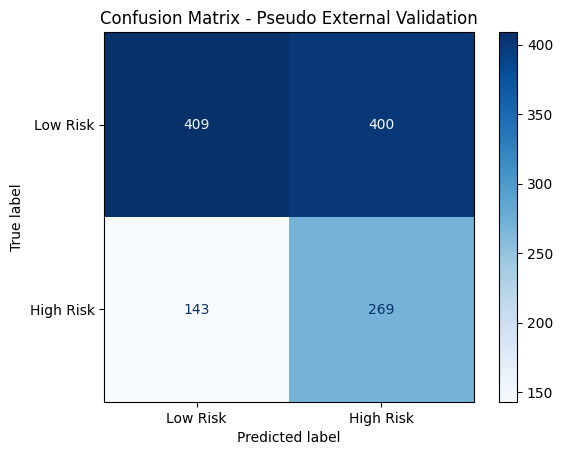


False Negative (High Risk terlewat): 143


In [ ]:
# ================================================
# PSEUDO EXTERNAL VALIDATION - Super Simpel
# ================================================

import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load dataset asli kamu
df = pd.read_csv("https://raw.githubusercontent.com/alifnw/3-Alif-Livyandra/refs/heads/livyandra/Mathernal_Risk.csv")

# Preprocessing FE-B-PP RC (sama seperti model kamu)
df = df.rename(columns={
    'Age': 'Age',
    'Systolic Blood Pressure(mm Hg)': 'Systolic BP',
    'Diastolic Blood Pressure(mm Hg)': 'Diastolic',
    'BMI(kg/m 2)': 'BMI',
    'Heart rate(bpm)': 'Heart Rate',
    'Body Temperature(F) ': 'Body Temp'
})

df['Pulse Pressure'] = df['Systolic BP'] - df['Diastolic']
df['MAP'] = (df['Systolic BP'] + 2 * df['Diastolic']) / 3
df['Is_Fever'] = (df['Body Temp'] > 99).astype(int)
df['Previous Complications'] = 0

# Mapping target → binary High vs Low (mid risk jadi Low)
df['Risk Level'] = df['Status'].map({'high risk': 1, 'mid risk': 0, 'low risk': 0})

# Split menjadi Pseudo External Test (20% data sebagai "data baru")
train_df, pseudo_test_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df['Risk Level']
)

print(f"Jumlah sampel Pseudo External Test: {len(pseudo_test_df)}")

# Load model terbaik kamu
with open('/content/drive/MyDrive/Maternal_Health_Model/best_model_final.pkl', 'rb') as f:
    payload = pickle.load(f)

model = payload['model']
feature_names = payload['feature_names']

# Prediksi
X_test = pseudo_test_df[feature_names]
y_test = pseudo_test_df['Risk Level']
y_pred = model.predict(X_test)

# Hasil
print("\n" + "="*70)
print("CLASSIFICATION REPORT — PSEUDO EXTERNAL VALIDATION")
print("="*70)
print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"], digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Pseudo External Validation")
plt.show()

print(f"\nFalse Negative (High Risk terlewat): {cm[1,0]}")

Jumlah sampel Pseudo External Test: 1221

CLASSIFICATION REPORT — PSEUDO EXTERNAL VALIDATION
              precision    recall  f1-score   support

    Low Risk     0.7308    0.5068    0.5985       809
   High Risk     0.3955    0.6335    0.4869       412

    accuracy                         0.5495      1221
   macro avg     0.5631    0.5701    0.5427      1221
weighted avg     0.6177    0.5495    0.5609      1221



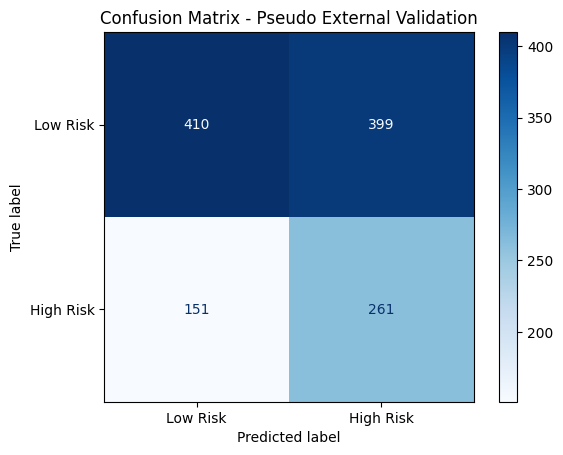


False Negative (High Risk terlewat): 151


In [ ]:
# ================================================
# PSEUDO EXTERNAL VALIDATION (Rekomendasi Utama)
# ================================================

import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load dataset asli kamu
df = pd.read_csv("https://raw.githubusercontent.com/alifnw/3-Alif-Livyandra/refs/heads/livyandra/Mathernal_Risk.csv")

# 2. Preprocessing FE-B-PP RC (sama persis seperti model kamu)
df = df.rename(columns={
    'Age': 'Age',
    'Systolic Blood Pressure(mm Hg)': 'Systolic BP',
    'Diastolic Blood Pressure(mm Hg)': 'Diastolic',
    'BMI(kg/m 2)': 'BMI',
    'Heart rate(bpm)': 'Heart Rate',
    'Body Temperature(F) ': 'Body Temp'
})

df['Pulse Pressure'] = df['Systolic BP'] - df['Diastolic']
df['MAP'] = (df['Systolic BP'] + 2 * df['Diastolic']) / 3
df['Is_Fever'] = (df['Body Temp'] > 99).astype(int)
df['Previous Complications'] = 0   # default

# Mapping target (mid risk dianggap Low Risk)
df['Risk Level'] = df['Status'].map({'high risk': 1, 'mid risk': 0, 'low risk': 0})

# 3. Buat Pseudo External Test Set (20% data sebagai "data baru")
train_df, pseudo_test = train_test_split(
    df,
    test_size=0.20,
    random_state=99,           # random_state berbeda dari training sebelumnya
    stratify=df['Risk Level']
)

print(f"Jumlah sampel Pseudo External Test: {len(pseudo_test)}")

# 4. Load model final kamu
with open('/content/drive/MyDrive/Maternal_Health_Model/best_model_final.pkl', 'rb') as f:
    payload = pickle.load(f)

model = payload['model']
feature_names = payload['feature_names']

# 5. Prediksi
X_test = pseudo_test[feature_names]
y_test = pseudo_test['Risk Level']
y_pred = model.predict(X_test)

# 6. Hasil
print("\n" + "="*75)
print("CLASSIFICATION REPORT — PSEUDO EXTERNAL VALIDATION")
print("="*75)
print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"], digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Pseudo External Validation")
plt.show()

print(f"\nFalse Negative (High Risk terlewat): {cm[1,0]}")